In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
RECORDS = ['100', '101', '103', '105', '106',
           '108', '109', '111', '112', '113']

def load_record_features(record_id):
    try:
        record = wfdb.rdrecord(record_id, pn_dir='mitdb')
        annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

        fs = record.fs
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        rr_intervals = np.diff(ann_samples)
        rr_ms = (rr_intervals / fs) * 1000
        heart_rate = 60000 / rr_ms
        rr_diff = np.append(0, np.diff(rr_ms))
        rolling_mean_rr = pd.Series(rr_ms).rolling( window=5, min_periods=1).mean().values
        rolling_std_rr = pd.Series(rr_ms).rolling( window=5, min_periods=1).std().fillna(0).values
        relative_rr = rr_ms / rolling_mean_rr

        df = pd.DataFrame({
            'record':  record_id,
            'sample':  ann_samples[1:],
            'symbol':  ann_symbols[1:],
            'rr_interval':  rr_ms,
            'heart_rate':  heart_rate,
            'rr_diff':  rr_diff,
            'rolling_mean_rr': rolling_mean_rr,
            'rolling_std_rr': rolling_std_rr,
            'relative_rr':  relative_rr,
        })
        return df

    except Exception as e:
        print(f"Record {record_id} failed - {e}")
        return None

all_records = []
for record_id in RECORDS:
    df = load_record_features(record_id)
    if df is not None:
        all_records.append(df)

combined_df = pd.concat(all_records, ignore_index=True)
print(f"Total beats: {len(combined_df)}")

Total beats: 21856


In [3]:
train_records = ['100', '101', '103', '105', '106', '108', '109', '111']
test_records = ['112', '113']

train_df = combined_df[combined_df['record'].isin(train_records)]
test_df = combined_df[combined_df['record'].isin(test_records)]

features = ['rr_interval', 'heart_rate', 'rr_diff', 'rolling_mean_rr', 'rolling_std_rr', 'relative_rr']

#Scale on training normal beats only
train_normal = train_df[train_df['symbol'] == 'N']
scaler = StandardScaler()
X_train_normal_flat = scaler.fit_transform(train_normal[features].values)
X_test_flat = scaler.transform(test_df[features].values)

print(f"Training normal beats: {len(X_train_normal_flat)}")
print(f"Test beats: {len(X_test_flat)}")

Training normal beats: 11953
Test beats: 4344


In [4]:
SEQUENCE_LENGTH = 10 #10 consecutive beats per sequence

def create_sequence(data, seq_length):
    """
    Convert a flat array of beats into overlapping sequences.

    Input shape:  (n_beats, n_features)
    Output shape: (n_beats - seq_length + 1, seq_length, n_features)

    Example with seq_length=10:
    Beats 0-9   -> sequence 0
    Beats 1-10  -> sequence 1
    Beats 2-11  -> sequence 2
    ... and so on (sliding window)
    """
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i : i + seq_length])
    return np.array(sequences)

#Create sequences from normal training beats
X_train_seq = create_sequence(X_train_normal_flat, SEQUENCE_LENGTH)

#Create sequences from test beats
X_test_seq = create_sequence(X_test_flat, SEQUENCE_LENGTH)

#Keep matching labels for test sequences
#Label of a sequence = label of its LAST beat
test_labels = test_df['symbol'].values
test_seq_labels = test_labels[SEQUENCE_LENGTH - 1:]

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape:  {X_test_seq.shape}")
print(f"Each sequence contains:   "
      f"{SEQUENCE_LENGTH} beats × {len(features)} features")

Training sequences shape: (11944, 10, 6)
Test sequences shape:  (4335, 10, 6)
Each sequence contains:   10 beats × 6 features


In [6]:
input_dim = len(features)  # 6 features
seq_len = SEQUENCE_LENGTH  # 10 time steps

#Input
inputs = Input(shape=(seq_len, input_dim))

#Encoder - two LSTM layers
#return_sequence = True - pass full sequence to next LSTM
#return_sequence = False - compress to single vector at end
encoded = LSTM(64, activation='tanh', return_sequences=True)(inputs)
encoded = LSTM(32, activation='tanh', return_sequences=False)(encoded)

#Bridge - repeat compressed vector across time steps
#so decoder receives a sequence not a single vector
bridged = RepeatVector(seq_len)(encoded)

#Decoder - mirror of encoder
decoded = LSTM(32, activation='tanh', return_sequences=True)(bridged)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)

#Output - reconstruct 6 features at every time step
outputs = TimeDistributed(Dense(input_dim, activation='linear'))(decoded)

#Wrap into model
lstm_autoencoder = Model(inputs=inputs, outputs=outputs)
lstm_autoencoder.compile(optimizer='adam', loss='mse')

lstm_autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 lstm_1 (LSTM)               (None, 10, 64)            18176     
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 repeat_vector (RepeatVector  (None, 10, 32)           0         
 )                                                               
                                                                 
 lstm_3 (LSTM)               (None, 10, 32)            8320      
                                                                 
 lstm_4 (LSTM)               (None, 10, 64)            24832     
                                                             

Epoch 1/100
336/336 [==============================] - 16s 27ms/step - loss: 0.4687 - val_loss: 0.6972
Epoch 2/100
336/336 [==============================] - 6s 18ms/step - loss: 0.3603 - val_loss: 0.6328
Epoch 3/100
336/336 [==============================] - 6s 18ms/step - loss: 0.3274 - val_loss: 0.5673
Epoch 4/100
336/336 [==============================] - 6s 19ms/step - loss: 0.2990 - val_loss: 0.5310
Epoch 5/100
336/336 [==============================] - 7s 21ms/step - loss: 0.2776 - val_loss: 0.4716
Epoch 6/100
336/336 [==============================] - 8s 24ms/step - loss: 0.2490 - val_loss: 0.4353
Epoch 7/100
336/336 [==============================] - 8s 25ms/step - loss: 0.2245 - val_loss: 0.3955
Epoch 8/100
336/336 [==============================] - 7s 20ms/step - loss: 0.2207 - val_loss: 0.4174
Epoch 9/100
336/336 [==============================] - 6s 18ms/step - loss: 0.1982 - val_loss: 0.3606
Epoch 10/100
336/336 [==============================] - 6s 19ms/step - loss: 0.18

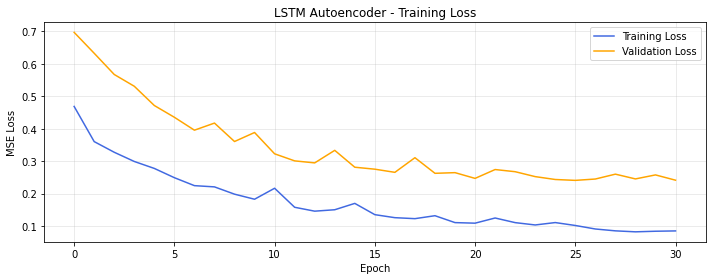

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_autoencoder.fit(
    X_train_seq, X_train_seq,   # input and output are the same
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],  label='Training Loss', color='royalblue')
plt.plot(history.history['val_loss'],  label='Validation Loss', color='orange')
plt.title('LSTM Autoencoder - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Reconstruct test sequences
X_test_reconstructed = lstm_autoencoder.predict(X_test_seq)

# MSE per sequence - mean across all time steps and features
test_errors = np.mean(
    np.power(X_test_seq - X_test_reconstructed, 2),
    axis=(1, 2)   # axis=1 averages across time steps
                  # axis=2 averages across features
)

# Threshold from training normal sequences
X_train_reconstructed = lstm_autoencoder.predict(X_train_seq)
train_errors = np.mean(
    np.power(X_train_seq - X_train_reconstructed, 2),
    axis=(1, 2)
)
threshold = np.percentile(train_errors, 95)

print(f"Threshold (95th percentile): {threshold:.6f}")
print(f"Normal seq mean error:  {train_errors.mean():.6f}")
print(f"Test seq mean error:  {test_errors.mean():.6f}")

374/374 [==============================] - 3s 7ms/step
Threshold (95th percentile): 0.530531
Normal seq mean error:  0.108217
Test seq mean error:  0.057352


In [9]:
# Flag anomalous sequences
anomaly_flags = (test_errors > threshold).astype(int)

# Split by patient
test_df_seq = test_df.iloc[SEQUENCE_LENGTH - 1:].copy()
test_df_seq = test_df_seq.reset_index(drop=True)
test_df_seq['reconstruction_error'] = test_errors
test_df_seq['anomaly_flag'] = anomaly_flags

print("--- LSTM Results on Unseen Patients ---\n")
for record_id in test_records:
    patient_df = test_df_seq[
        test_df_seq['record'] == record_id]
    true_abnormal = patient_df[patient_df['symbol'] != 'N']
    caught = true_abnormal[true_abnormal['anomaly_flag'] == 1]
    false_pos = patient_df[
        (patient_df['anomaly_flag'] == 1) &
        (patient_df['symbol'] == 'N')
    ]

    print(f"Patient {record_id}:")
    print(f"Total sequences:  {len(patient_df)}")
    print(f"True abnormal:   {len(true_abnormal)}")
    print(f"Caught:  {len(caught)}")
    print(f"False positives:  {len(false_pos)}")
    if len(true_abnormal) > 0:
        print(f"Detection rate:  "
              f"{len(caught)/len(true_abnormal)*100:.1f}%")
    print()

--- LSTM Results on Unseen Patients ---

Patient 112:
Total sequences:  2540
True abnormal:   12
Caught:  3
False positives:  14
Detection rate:  25.0%

Patient 113:
Total sequences:  1795
True abnormal:   6
Caught:  1
False positives:  10
Detection rate:  16.7%



In [10]:
print("PHASE 7 (Autoencoder) vs PHASE 8 (LSTM) - Comparison")
print()

phase7_results = {
    '112': {'caught': 11, 'total': 12,
            'false_pos': 18,  'rate': 91.7},
    '113': {'caught': 6,  'total': 6,
            'false_pos': 174, 'rate': 100.0},
}

print(f"\n{'Patient':<10} {'Model':<20} "
      f"{'Caught':<10} {'False+':<10} {'Rate':<10}")
print("-"*60)

for record_id in test_records:
    p7 = phase7_results[record_id]
    patient_df = test_df_seq[
        test_df_seq['record'] == record_id]
    true_abnormal = patient_df[patient_df['symbol'] != 'N']
    caught = true_abnormal[true_abnormal['anomaly_flag'] == 1]
    false_pos = patient_df[
        (patient_df['anomaly_flag'] == 1) &
        (patient_df['symbol'] == 'N')
    ]
    rate = (len(caught)/len(true_abnormal)*100
            if len(true_abnormal) > 0 else 0)

    print(f"{record_id:<10} {'Autoencoder':<20} "
          f"{p7['caught']}/{p7['total']:<7} "
          f"{p7['false_pos']:<10} "
          f"{p7['rate']:.1f}%")
    print(f"{'':<10} {'LSTM':<20} "
          f"{len(caught)}/{len(true_abnormal):<7} "
          f"{len(false_pos):<10} "
          f"{rate:.1f}%")
    print()

PHASE 7 (Autoencoder) vs PHASE 8 (LSTM) - Comparison


Patient    Model                Caught     False+     Rate      
------------------------------------------------------------
112        Autoencoder          11/12      18         91.7%
           LSTM                 3/12      14         25.0%

113        Autoencoder          6/6       174        100.0%
           LSTM                 1/6       10         16.7%



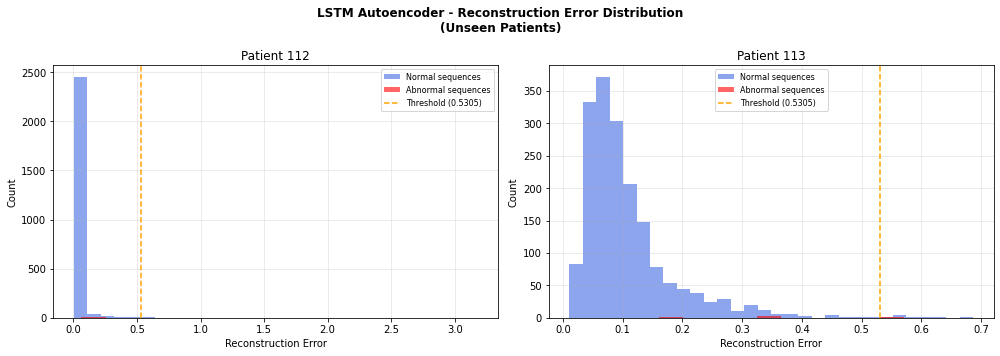

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Autoencoder - Reconstruction Error Distribution'
             '\n(Unseen Patients)',
             fontsize=12, fontweight='bold')

for idx, record_id in enumerate(test_records):
    patient_df = test_df_seq[
        test_df_seq['record'] == record_id]

    normal_err = patient_df[
        patient_df['symbol'] == 'N']['reconstruction_error']
    abnormal_err = patient_df[
        patient_df['symbol'] != 'N']['reconstruction_error']

    axes[idx].hist(normal_err, bins=30, alpha=0.6, color='royalblue', label='Normal sequences')
    axes[idx].hist(abnormal_err, bins=10, alpha=0.6, color='red', label='Abnormal sequences')
    axes[idx].axvline(x=threshold, color='orange', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.4f})')
    axes[idx].set_title(f'Patient {record_id}')
    axes[idx].set_xlabel('Reconstruction Error')
    axes[idx].set_ylabel('Count')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase8_lstm.png', dpi=150, bbox_inches='tight')
plt.show()